<a href="https://colab.research.google.com/github/R12-l/2023-Java-creando-tu-primera-aplicacion/blob/aula-1/Ecualizada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/

/content/drive/MyDrive


In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 19.1 MB/s eta 0:00:00


In [ ]:
!pip install dicom2nifti

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 74.0 MB/s eta 0:00:00


In [ ]:
# Importar librerías específicas
import dicom2nifti
from pathlib import Path
import nibabel as nib
import matplotlib.pyplot as plt
import pydicom

In [ ]:
dicom_file = pydicom.dcmread('/content/drive/MyDrive/Colab Notebooks/ID_0004_AGE_0056_CONTRAST_1_CT.dcm')

In [ ]:
print(dicom_file)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 194
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.14519.5.2.1.7777.9002.154181272448537806873380883469
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.40.0.13.1.1.1
(0002,0013) Implementation Version Name         SH: 'dcm4che-1.4.31'
-------------------------------------------------
(0008,0000) Group Length                        UL: 436
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL', 'CT_SOM4 SPI']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.14519.5.2.1.7777.9002.1

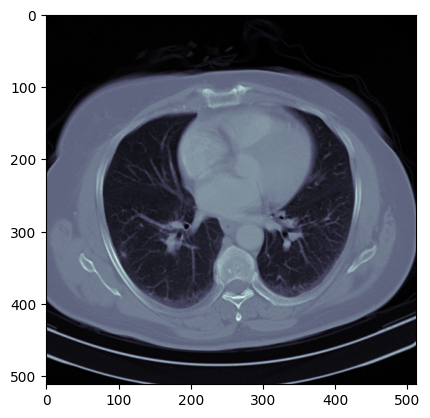

In [ ]:
ct_2 = dicom_file.pixel_array
plt.figure()
plt.imshow(ct_2, cmap = 'bone')

(0.0, 10000.0)

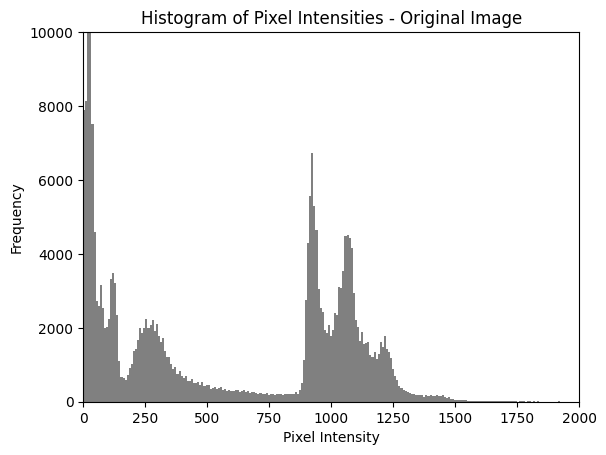

In [ ]:
# Histograma de la Imagen Original
plt.figure()
plt.hist(ct_2.ravel(), bins = 256, color = 'gray')
plt.title('Histogram of Pixel Intensities - Original Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

plt.xlim(0, 2000)
plt.ylim(0, 10000)

In [ ]:
# Ecualización del histograma
from skimage import exposure

In [ ]:
ct_equalized = exposure.equalize_hist(ct_2)

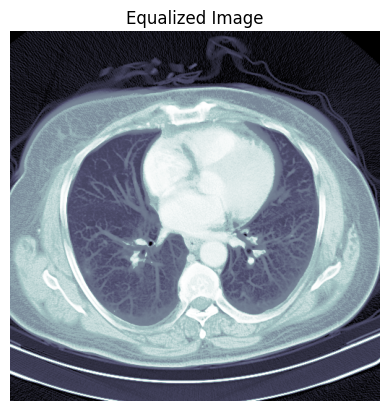

In [ ]:
plt.figure()
plt.imshow(ct_equalized, cmap = 'bone')
plt.title('Equalized Image')
plt.axis('off')
plt.show()

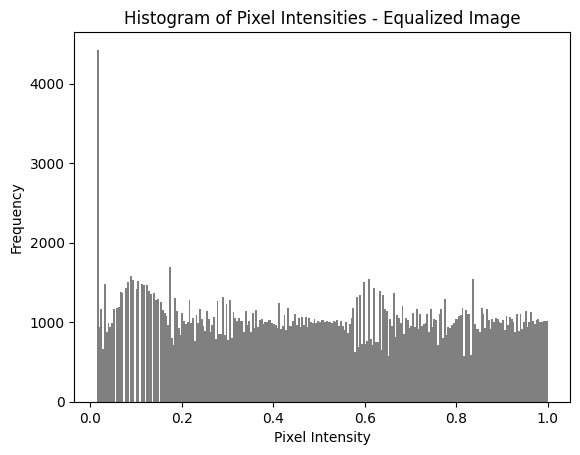

In [ ]:
# Histograma de la Imagen Ecualizada
plt.figure()
plt.hist(ct_equalized.ravel(), bins = 256, color = 'gray')
plt.title('Histogram of Pixel Intensities - Equalized Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()